# **Cargar el modelo**

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pickle

# Cargar datos
filename = '/content/hp_modelos_gs.pkl'
with open(filename, 'rb') as file:
    datos = pickle.load(file)

# Extraer elementos
# Modelos
model_boos = datos['models']['boosting']
model_rf = datos['models']['random_forest']
model_rn = datos['models']['red_neuronal']

# Datos sin normalizar
X_train = datos['data_raw']['X_train']
X_test = datos['data_raw']['X_test']
Y_train = datos['data_raw']['Y_train']
Y_test = datos['data_raw']['Y_test']
X = datos['data_raw']['X_full']
Y = datos['data_raw']['Y_full']

# Datos normalizados
X_train_scaled = datos['data_scaled']['X_train_scaled']
X_test_scaled = datos['data_scaled']['X_test_scaled']
Y_train_scaled = datos['data_scaled']['Y_train_scaled']
Y_test_scaled = datos['data_scaled']['Y_test_scaled']

# Scalers
min_max_scaler_X = datos['scalers']['scaler_X']
min_max_scaler_Y = datos['scalers']['scaler_Y']
var_num = datos['scalers']['var_num']

# Configuración
cv = datos['config']['cv']
scoring = datos['config']['scoring']

print("✅ Datos cargados exitosamente")
print(f"📊 X_train shape: {X_train.shape}")
print(f"📊 Y_train shape: {Y_train.shape}")


✅ Datos cargados exitosamente
📊 X_train shape: (1022, 273)
📊 Y_train shape: (1022,)


# **Hiperparametrizacion con Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Definimos los parametros
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [2, 3, 4],
    'min_samples_split': [2, 5]
}

# Creamos el grid search
grid_search_rf = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=10
                              ,scoring='r2', n_jobs=-1, return_train_score=True)

# Fit la data con el grid search
grid_search_rf.fit(X_train, Y_train)

#Mejor modelo
modelRF= grid_search_rf.best_estimator_
Y_pred_rf = modelRF.predict(X_test)

# R2 del mejor modelo
r2_rf_gs = r2_score(Y_test, Y_pred_rf)
mae_rf_gs = mean_absolute_error(Y_test, Y_pred_rf)

# Mejores párametros
print("Mejores parametros para Random Forest Grid Search:")
print(grid_search_rf.best_params_)
print(f"\n📊 R² en Test: {r2_rf_gs:.6f}")
print(f"📊 MAE en Test: {mae_rf_gs:.2f}")
print(f"📊 R² CV (validación cruzada): {grid_search_rf.best_score_:.6f}")


Mejores parametros para Random Forest Grid Search:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

📊 R² en Test: 0.838309
📊 MAE en Test: 19349.77
📊 R² CV (validación cruzada): 0.815746


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos los parametros para AdaBoost
param_grid_boost = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05],
    'estimator__max_depth': [2, 5, 10],  # Para el DecisionTreeRegressor base
    'estimator__min_samples_leaf': [2, 3, 4]
}

# Crear el grid search
grid_search_boost = GridSearchCV(estimator=model_boos, param_grid=param_grid_boost,
                                    cv=10, scoring='r2', n_jobs=-1, return_train_score=True)

# Fit la data con el grid search
grid_search_boost.fit(X_train, Y_train)

# Mejor modelo
modelBoost = grid_search_boost.best_estimator_
Y_pred_boost = modelBoost.predict(X_test)

# Calculamos el R2 para el mejor modelo
r2_boost_gs = r2_score(Y_test, Y_pred_boost)
mae_boost_gs = mean_absolute_error(Y_test, Y_pred_boost)

# Mejores párametros
print("Mejores parametros para Random Forest Grid Search:")
print(grid_search_boost.best_params_)
print(f"\n📊 R² en Test: {r2_boost_gs:.6f}")
print(f"📊 MAE en Test: {mae_boost_gs:.2f}")
print(f"📊 R² CV (validación cruzada): {grid_search_boost.best_score_:.6f}")


Mejores parametros para Random Forest Grid Search:
{'estimator__max_depth': 10, 'estimator__min_samples_leaf': 3, 'learning_rate': 0.05, 'n_estimators': 100}

📊 R² en Test: 0.833482
📊 MAE en Test: 19787.86
📊 R² CV (validación cruzada): 0.812538


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos los parametros RN
param_grid_rn = {
    'activation': ['relu', 'tanh'],
    'hidden_layer_sizes': [(200, 200), (250, 150)],
    'learning_rate': ['adaptive','constant'],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'momentum': [0.3, 0.4],
    'max_iter': [1000, 10000],
    'alpha': [0.0001, 0.001]
}

# Crear el grid search
grid_search_rn = GridSearchCV(estimator=model_rn, param_grid=param_grid_rn,
                                    cv=10, scoring='r2', n_jobs=-1, return_train_score=True)

# Fit la data con el grid search
grid_search_rn.fit(X_train_scaled, Y_train_scaled)

# Mejor modelo
modelRn = grid_search_rn.best_estimator_
Y_pred_rn = modelRn.predict(X_test_scaled)

# Calculamos el R2 para el mejor modelo
r2_rn_gs = r2_score(Y_test_scaled, Y_pred_rn)
mae_rn_gs = mean_absolute_error(Y_test_scaled, Y_pred_rn)

# Mejores párametros
print("Mejores parametros para Random Forest Grid Search:")
print(grid_search_rn.best_params_)
print(f"\n📊 R² en Test: {r2_rn_gs:.6f}")
print(f"📊 MAE en Test: {mae_rn_gs:.2f}")
print(f"📊 R² CV (validación cruzada): {grid_search_rn.best_score_:.6f}")

Mejores parametros para Random Forest Grid Search:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (200, 200), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'max_iter': 1000, 'momentum': 0.3}

📊 R² en Test: 0.808730
📊 MAE en Test: 0.03
📊 R² CV (validación cruzada): 0.829240


# **Hiperparametrizacion con algoritmos geneticos**

In [ ]:
!pip install sklearn-genetic-opt

Random Forest

In [ ]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
from sklearn_genetic.plots import plot_fitness_evolution, plot_search_space
from sklearn.model_selection import StratifiedKFold

param_grid_rf = {'max_depth': Integer(4, 10),
              'min_samples_leaf': Integer(2, 5),
              'n_estimators': Integer(100, 250)
              }

evolved_estimator_rf = GASearchCV(estimator=model_rf,
                               cv=10, #10
                               scoring='r2', #maximiza scoring
                               population_size=20, #tamaño de la población es constante
                               generations=15, #generaciones o iteraciones
                               elitism=True, #selección de padres
                               crossover_probability=0.4, #porcentaje para hacer recombinación
                               mutation_probability=0.6, #porcentaje de mutación
                               param_grid=param_grid_rf,
                               criteria='max',
                               verbose=True,
                               n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.802004	0.0168662  	0.815633   	0.756025   
1  	40    	0.811426	0.00698977 	0.816058   	0.786087   
2  	40    	0.815062	0.000974304	0.816362   	0.813235   
3  	40    	0.815487	0.00111952 	0.816362   	0.812102   
4  	40    	0.815927	0.000975134	0.816362   	0.812102   
5  	40    	0.816409	0.00025645 	0.816994   	0.816153   
6  	40    	0.816575	0.000289463	0.816994   	0.816189   
7  	40    	0.816768	0.000295142	0.816994   	0.816013   
8  	40    	0.816901	0.000202444	0.817098   	0.816362   
9  	40    	0.816654	0.00145896 	0.817027   	0.810298   
10 	40    	0.816946	0.000208801	0.816994   	0.816036   
11 	40    	0.816916	0.000237225	0.816994   	0.816071   
12 	40    	0.816982	4.96611e-05	0.816994   	0.816766   
13 	40    	0.816962	0.000101046	0.816994   	0.816578   
14 	40    	0.816994	3.33067e-16	0.816994   	0.816994   
15 	40    	0.816659	0.00145939 	0.816994   	0.810298   
{'max_depth': 10, 'min_samples_leaf': 5, 'n_esti

/tmp/ipython-input-2923811580.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


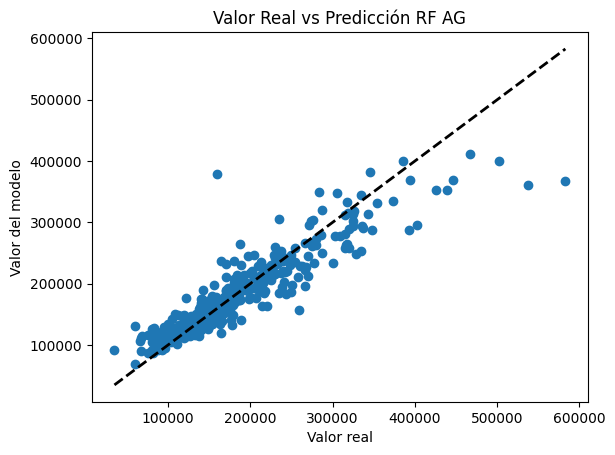

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
#Aprendizaje
evolved_estimator_rf.fit(X_train,Y_train) #70%

#Mejor modelo
best_params_rf_ag = evolved_estimator_rf.best_params_
genetics_best_model_rf= evolved_estimator_rf.best_estimator_

#Evaluación
Y_pred_rf_ag= genetics_best_model_rf.predict(X_test) #30%

#Calcular R2 y MAE
r2_rf_ag = r2_score(Y_test, Y_pred_rf_ag)
mae_rf_ag = mean_absolute_error(Y_test, Y_pred_rf_ag)

print(best_params_rf_ag)
print(f"\n📊 R² en Test: {r2_rf_ag:.6f}")
print(f"📊 MAE en Test: {mae_rf_ag:.2f}")
print(f"📊 R² CV (validación cruzada): {evolved_estimator_rf.best_score_:.6f}")


#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred_rf_ag)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción RF AG')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

Boosting

In [ ]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
from sklearn_genetic.plots import plot_fitness_evolution, plot_search_space
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, r2_score

param_grid_boost_ag = {'estimator__max_depth': Integer(4,10),
              'learning_rate': Continuous(0.001, 0.04),
              'n_estimators': Integer(100, 200),
             'estimator__min_samples_leaf': Integer(2,5),
              }

evolved_estimator_boost = GASearchCV(estimator=model_boos,
                               cv=10, #10
                               scoring='r2', #maximiza scoring
                               population_size=20, #tamaño de la población es constante
                               generations=20, #generaciones o iteraciones
                               elitism=True, #selección de padres
                               crossover_probability=0.4, #porcentaje para hacer recombinación
                               mutation_probability=0.6, #porcentaje de mutación
                               param_grid=param_grid_boost_ag,
                               criteria='max',
                               verbose=True,
                                n_jobs=-1)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.783282	0.0218872  	0.808357   	0.739758   
1  	40    	0.796209	0.0116465  	0.81338    	0.76077    
2  	40    	0.804651	0.00520783 	0.81338    	0.795028   
3  	40    	0.808111	0.0035392  	0.81338    	0.802246   
4  	40    	0.811454	0.00238966 	0.815014   	0.805885   
5  	40    	0.812965	0.00170672 	0.815386   	0.810189   
6  	40    	0.812638	0.00180158 	0.815386   	0.808937   
7  	40    	0.813254	0.00182767 	0.815386   	0.809163   
8  	40    	0.813759	0.00196806 	0.815386   	0.809163   
9  	40    	0.815245	0.000244425	0.815386   	0.814437   
10 	40    	0.81452 	0.00168277 	0.815386   	0.809987   
11 	40    	0.814713	0.00173873 	0.815386   	0.809406   
12 	40    	0.814441	0.00195114 	0.815386   	0.809617   
13 	40    	0.814949	0.0011511  	0.815386   	0.810673   
14 	40    	0.815386	0          	0.815386   	0.815386   
15 	40    	0.814778	0.00198489 	0.815489   	0.8069     
16 	40    	0.815197	0.000811389	0.815386   	0.81

/tmp/ipython-input-13521066.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


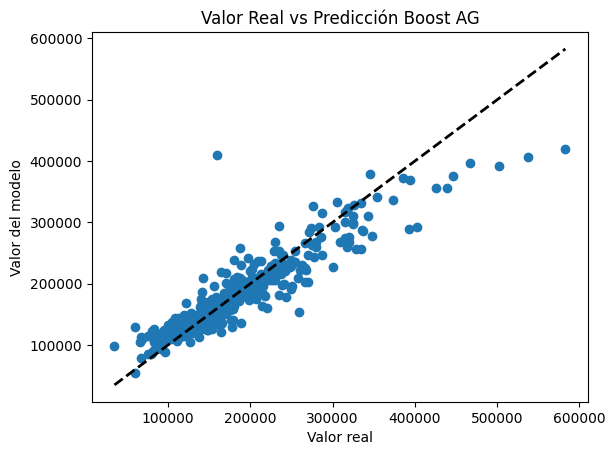

In [ ]:
#Aprendizaje
evolved_estimator_boost.fit(X_train,Y_train) #70%

#Mejor modelo
best_params_boost= evolved_estimator_boost.best_params_
genetics_best_model_boost= evolved_estimator_boost.best_estimator_

#Evaluación
Y_pred_boost_ag= genetics_best_model_boost.predict(X_test) #30%

#Calcular r2 y MAE
r2_boost_ag = r2_score(Y_test, Y_pred_boost_ag)
mae_boost_ag = mean_absolute_error(Y_test, Y_pred_boost_ag)

print(best_params_boost)
print(f"\n📊 R² en Test: {r2_boost_ag:.6f}")
print(f"📊 MAE en Test: {mae_boost_ag:.2f}")
print(f"📊 R² CV (validación cruzada): {evolved_estimator_boost.best_score_:.6f}")



#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred_boost_ag)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Boost AG')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

Red Neuronal

In [ ]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
from sklearn_genetic.plots import plot_fitness_evolution, plot_search_space
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, r2_score

param_grid_rn_ag= {'activation': Categorical(['relu', 'tanh']),
                   'solver': Categorical(['adam', 'sgd']),
              'hidden_layer_sizes': Categorical([(200, 200), (250, 150), (150,150)]),
              'momentum': Continuous(0.2, 0.4),
              'max_iter': Integer(100, 1000),
              'alpha': Continuous(0.0001, 0.001),
              'learning_rate_init': Continuous(0.0001, 0.01)
              }

evolved_estimator_rn = GASearchCV(estimator=model_rn,
                               cv=10, #10
                               scoring='r2', #maximiza scoring
                               population_size=20, #tamaño de la población es constante
                               generations=25, #generaciones o iteraciones
                               elitism=True, #selección de padres
                               crossover_probability=0.4, #porcentaje para hacer recombinación
                               mutation_probability=0.6, #porcentaje de mutación
                               param_grid=param_grid_rn_ag,
                               criteria='max',
                               verbose=True)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.627866	0.212704   	0.832339   	0.104657   


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (177) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (177) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (177) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (177) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

1  	40    	0.797968	0.0403637  	0.822498   	0.651586   


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (510) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (510) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (510) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (301) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (301) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (301) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (301) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

21 	40    	0.842022	1.11022e-16	0.842022   	0.842022   


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (114) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (114) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (114) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (114) reached and the optimization hasn't converged yet.
  warnings.warn(


22 	40    	0.836321	0.0248506  	0.842022   	0.728      
23 	40    	0.842022	1.11022e-16	0.842022   	0.842022   
24 	40    	0.842022	1.11022e-16	0.842022   	0.842022   
25 	40    	0.841882	0.000611129	0.842022   	0.839218   
{'activation': 'relu', 'solver': 'adam', 'hidden_layer_sizes': (200, 200), 'momentum': np.float64(0.25778540736420474), 'max_iter': 114, 'alpha': np.float64(0.0003554390208368552), 'learning_rate_init': np.float64(0.009761003141882958)}

📊 R² en Test: 0.800239
📊 MAE en Test: 0.03
📊 R² CV (validación cruzada): 0.842022


/tmp/ipython-input-3819630556.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


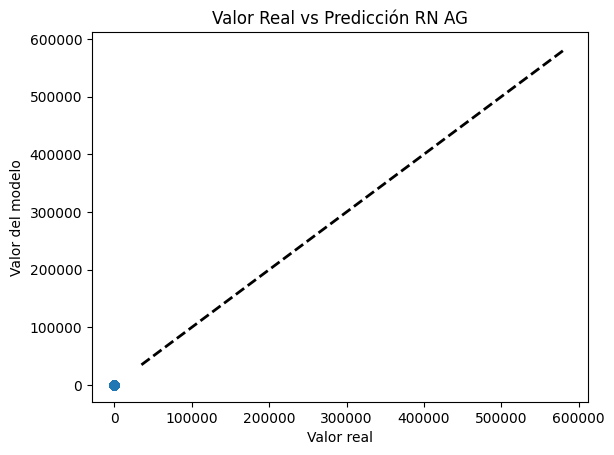

In [ ]:
#Aprendizaje
evolved_estimator_rn.fit(X_train_scaled,Y_train_scaled) #70%

#Mejor modelo
best_params_rn_ag= evolved_estimator_rn.best_params_
genetics_best_model_rn= evolved_estimator_rn.best_estimator_

#Evaluación
Y_pred_rn_ag= genetics_best_model_rn.predict(X_test_scaled) #30%

#Calcular R2 y MAE
r2_rn_ag = r2_score(Y_test_scaled, Y_pred_rn_ag)
mae_rn_ag = mean_absolute_error(Y_test_scaled, Y_pred_rn_ag)

print(best_params_rn_ag)
print(f"\n📊 R² en Test: {r2_rn_ag:.6f}")
print(f"📊 MAE en Test: {mae_rn_ag:.2f}")
print(f"📊 R² CV (validación cruzada): {evolved_estimator_rn.best_score_:.6f}")


#Gráfica Valor Real vs Predicción
plt.scatter(Y_test_scaled, Y_pred_rn_ag)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción RN AG')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

# **EVALUACION Y GUARDAMOS MODELO**

In [ ]:
#Guardamos el modelo final
filename = 'Modelo_FINAL.pkl'
variables= X.columns._values
pickle.dump([modelRF,variables], open(filename, 'wb')) #write